In [79]:
import pandas as pd
import numpy as np
import os, glob
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error, mean_squared_log_error, root_mean_squared_error, root_mean_squared_error

In [16]:
df = pd.read_csv('./total_data.csv')
raw_data = df[['DFT', '7net-0', '7net-l3i5', '7net-omat',
       '7net-ompa-mpa', '7net-ompa-omat24', '7net-omni-omat24',
       '7net-omni-mpa', 'orb_mpa', 'orb_omat', 'esen_oam', 'esen_omat',]]
raw_data.to_csv('./raw_data.csv', index=False)
true_value = df['DFT']
mlips = raw_data.drop(columns=['DFT'])
mlips.to_csv('./mlips.csv', index=False)

In [100]:
len(mlips.columns)
mlip_list = mlips.columns.to_list()
config_list = [
    "a1", "a2",
    "b1", "b2", "b3",
    "c1", "c2",
    "d", "e", "f", "g", "h", "i",
    "j", "k",
]
len(config_list)

15

In [101]:
sns_df = pd.DataFrame(columns=['config','dft', 'mlip', 'pred','delta','abs_error'], index=range(11*15))
idx = 0
for i in range(15):
    for mlip in mlips.columns:
        sns_df.loc[idx, 'config'] = config_list[i]
        sns_df.loc[idx, 'dft'] = true_value[i]
        sns_df.loc[idx, 'mlip'] = mlip
        sns_df.loc[idx, 'pred'] = mlips.loc[i, mlip]
        sns_df.loc[idx, 'delta'] = mlips.loc[i, mlip] - true_value[i]
        sns_df.loc[idx, 'abs_error'] = abs(mlips.loc[i, mlip] - true_value[i])
        idx += 1
sns_df.to_csv('./sns_data.csv', index=False)

In [99]:
metrics = pd.DataFrame(columns = mlips.columns)
for col in mlips.columns:
    pred_value = mlips[col]
    metrics.loc['MAE', col] = mean_absolute_error(true_value, pred_value)
    metrics.loc['MSE', col] = mean_squared_error(true_value, pred_value)
    metrics.loc['RMSE', col] = np.sqrt(mean_squared_error(true_value, pred_value))
    metrics.loc['R2', col] = r2_score(true_value, pred_value)
    # metrics.loc['Explained Variance', col] = explained_variance_score(true_value, pred_value)
    metrics.loc['MAPE', col] = mean_absolute_percentage_error(true_value, pred_value)
    try:
        metrics.loc['MSLE', col] = mean_squared_log_error(true_value, pred_value)
        metrics.loc['RMSLE', col] = np.sqrt(mean_squared_log_error(true_value, pred_value))
    except:
        metrics.loc['MSLE', col] = 'NA'
        metrics.loc['RMSLE', col] = 'NA'
metrics.to_csv('./mlip_metric.csv')
print(metrics)



         7net-0 7net-l3i5 7net-omat 7net-ompa-mpa 7net-ompa-omat24  \
MAE    0.271125   0.55456  0.189185      0.224597         0.244258   
MSE     0.13319   0.46054  0.072769      0.094476         0.107484   
RMSE   0.364951  0.678631  0.269758       0.30737         0.327848   
R2     0.731173  0.070454  0.853124       0.80931         0.783056   
MAPE   1.581783   4.03633  0.700134      1.893772         2.146718   
MSLE         NA        NA        NA            NA               NA   
RMSLE        NA        NA        NA            NA               NA   

      7net-omni-omat24 7net-omni-mpa   orb_mpa  orb_omat  esen_oam esen_omat  
MAE           0.203856      0.211286  0.198242  0.162272  0.144843  0.148172  
MSE           0.066835       0.07199  0.049503  0.043231  0.035022  0.035882  
RMSE          0.258525       0.26831  0.222493   0.20792  0.187141  0.189426  
R2            0.865101      0.854696  0.900084  0.912744  0.929313  0.927576  
MAPE          1.334508      1.278664  1.4144

15

In [109]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica','Arial']
# plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titlelocation'] = 'right'
plt.rcParams['axes.titlepad'] = 3

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.labelbottom'] = True    
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.loc'] = 'lower right'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

plt.rcParams['xtick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.3

plt.rcParams['ytick.major.size'] = 7
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 0.3
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.facecolor'] = 'white'

plt.rcParams['figure.figsize'] = 3.4, 2.5
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.subplot.bottom'] = 0.15
plt.rcParams['figure.subplot.left'] = 0.15
plt.rcParams['figure.subplot.right'] = 0.95
plt.rcParams['figure.subplot.top'] = 0.9
plt.rcParams['figure.subplot.wspace'] = 0.15
plt.rcParams['figure.subplot.hspace'] = 0.15


color_dict= {
    '7net-ompa-omat24': '#2677e0',
    '7net-ompa-mpa': '#003780',
    '7net-omat': '#de6000',
    '7net-omni-omat24': '#fa4365',
    '7net-omni-mpa': '#8a0019',
    '7net-l3i5': '#004d0a',
    '7net-0': '#00ba19',
    'orb_omat': '#c6c78f',
    'orb_mpa': '#94860d',
    'esen_omat':'#99adad',
    'esen_oam': '#5c7070',
    
}

7net-ompa-omat24
7net-omni-omat24
orb_omat
esen_omat


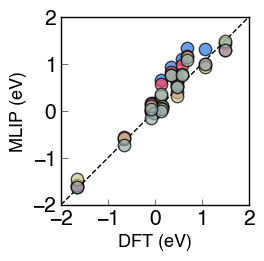

In [66]:
fig, axes = plt.subplots()
for col in mlips.columns:
    if '7net' in col:
        if '-mpa' in col or 'l3i5' in col or '7net-omat' in col or '7net-0' in col:
            continue
        else:
            axes.scatter(true_value, mlips[col], s=80, label=col, alpha=0.7, zorder=2, color=color_dict[col],edgecolors='k',)
            print(col)
    elif 'omat' in col:
        axes.scatter(true_value, mlips[col], s=80, label=col, alpha=0.7, zorder=2, color=color_dict[col],edgecolors='k',)
        print(col)
axes.plot([-10, 10], [-10, 10], color='black', linestyle='--', linewidth=1, zorder=1)
axes.set_xlim(-2,2)
axes.set_ylim(-2, 2)
xticks = [-2, -1, 0, 1, 2]
yticks = [-2, -1, 0, 1, 2]
axes.set_xticks(xticks)
axes.set_yticks(yticks)

axes.set_xlabel('DFT (eV)')
axes.set_ylabel('MLIP (eV)')

    
axes.set_box_aspect(1)

/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_88274/4210688354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


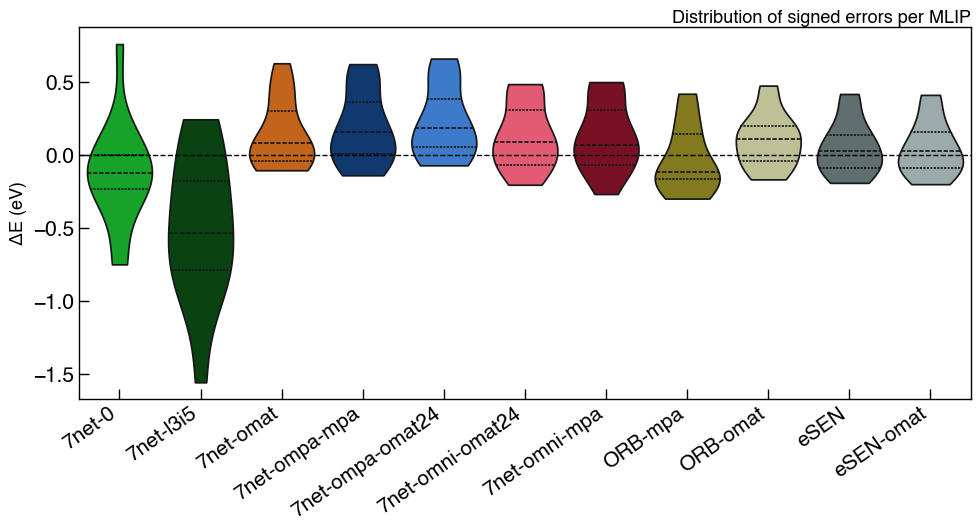

In [111]:
plt.figure(figsize=(10,5.5))
sns.violinplot(
    data=sns_df,
    x="mlip",
    y="delta",          # <--- signed error
    inner="quartile",
    cut=0,
    palette=color_dict
)
plt.axhline(0, color="k", linestyle="--", linewidth=1)  # reference line
plt.xticks(rotation=35, ha="right")
plt.ylabel("ΔE (eV)")
plt.xlabel("")
plt.xticks(ticks=range(len(mlip_list)), labels=['7net-0', '7net-l3i5', '7net-omat', '7net-ompa-mpa', '7net-ompa-omat24', '7net-omni-omat24', '7net-omni-mpa', 'ORB-mpa', 'ORB-omat', 'eSEN', 'eSEN-omat'])
plt.title("Distribution of signed errors per MLIP")
# sns.despine()
plt.tight_layout()
plt.show()

In [120]:
sns_df['mlip']

0                7net-0
1             7net-l3i5
2             7net-omat
3         7net-ompa-mpa
4      7net-ompa-omat24
             ...       
160       7net-omni-mpa
161             orb_mpa
162            orb_omat
163            esen_oam
164           esen_omat
Name: mlip, Length: 165, dtype: object

/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_88274/2854138275.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


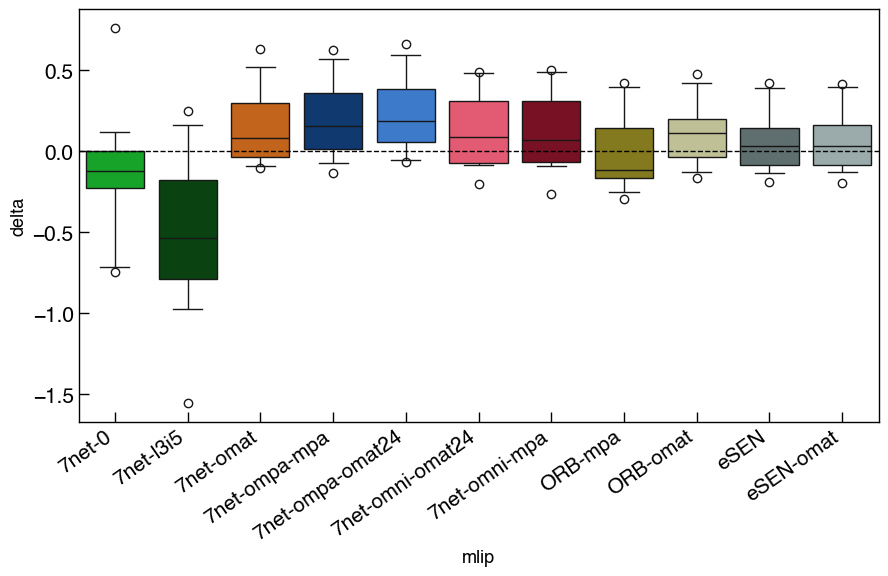

In [115]:
plt.figure(figsize=(10,5.5))
plt.xticks(rotation=35, ha="right")

sns.boxplot(
    data=sns_df,
    x="mlip",
    y="delta",
    palette=color_dict,
    whis=(5, 95),
    showfliers=True
)
plt.xticks(ticks=range(len(mlip_list)), labels=['7net-0', '7net-l3i5', '7net-omat', '7net-ompa-mpa', '7net-ompa-omat24', '7net-omni-omat24', '7net-omni-mpa', 'ORB-mpa', 'ORB-omat', 'eSEN', 'eSEN-omat'])
plt.axhline(0, color="k", linestyle="--", linewidth=1)  # reference line

# plt.axhline(0, color="k", linestyle="--", linewidth=1)(metrics)

In [117]:
sns_dict

NameError: name 'sns_dict' is not defined

In [118]:
sns_df

,config,dft,mlip,pred,delta,abs_error
0,a1,0.47,7net-0,0.286011,-0.183989,0.183989
1,a1,0.47,7net-l3i5,-0.101562,-0.571562,0.571562
2,a1,0.47,7net-omat,0.695068,0.225068,0.225068
3,a1,0.47,7net-ompa-mpa,0.704224,0.234224,0.234224
4,a1,0.47,7net-ompa-omat24,0.725708,0.255708,0.255708
...,...,...,...,...,...,...
160,k,1.5,7net-omni-mpa,1.235962,-0.264038,0.264038
161,k,1.5,orb_mpa,1.248413,-0.251587,0.251587
162,k,1.5,orb_omat,1.491333,-0.008667,0.008667
163,k,1.5,esen_oam,1.3125,-0.1875,0.1875
